# Project NLP :

# Arabic Dialect Identification Using Logistic Regression ( TF-IDF ) and MARBERT

**اسماء الطالبات :**

**ريوف الشريف - ميار العويضي - جنى الحليس**

# Data Exploration and Loading

In [ ]:
!pip install -q transformers datasets accelerate evaluate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset, DatasetDict
import evaluate
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

In [ ]:
df = pd.read_csv('/content/df_train (4).csv')

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (112000, 7)
Columns: ['lang', 'sent', 'city', 'country_id', 'country', 'city_id', 'source']

First 5 rows:


,lang,sent,city,country_id,country,city_id,source
0,JER,هناك، قدام مكتب استعلامات السياح بالزبط.,Jerusalem,11,palestine,0,MADAR
1,JER,عمري ما سمعت هدا العنوان هون.,Jerusalem,11,palestine,0,MADAR
2,JER,خليك ماشي دغري لتلاقي صيدلية.,Jerusalem,11,palestine,0,MADAR
3,JER,قديش الفطور؟,Jerusalem,11,palestine,0,MADAR
4,JER,كيف بقدر أساعدك؟,Jerusalem,11,palestine,0,MADAR


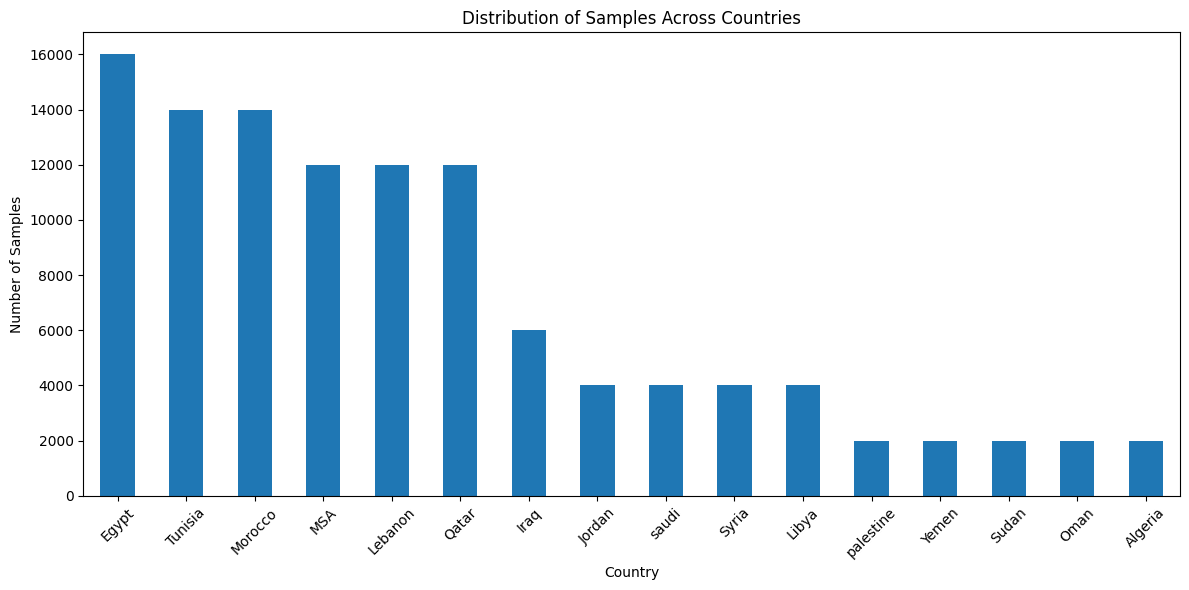

In [ ]:
country_counts = df['country'].value_counts()

# Bar Chart
plt.figure(figsize=(12,6))
country_counts.plot(kind='bar')

plt.title("Distribution of Samples Across Countries")
plt.xlabel("Country")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Data Preprocessing

In [ ]:
# Automatic detection of text & label columns
possible_text_cols = ['text', 'tweet', 'content', 'sentence', 'utterance', 'comment']
possible_label_cols = ['label', 'dialect', 'dialects', 'country', 'class', 'y']

TEXT_COL = 'sent'
LABEL_COL = 'country'

for c in df.columns:
    if c.lower() in possible_text_cols and TEXT_COL is None:
        TEXT_COL = c
    if c.lower() in possible_label_cols and LABEL_COL is None:
        LABEL_COL = c

In [ ]:
print(f"\nUsing TEXT_COL = '{TEXT_COL}' and LABEL_COL = '{LABEL_COL}'")
print("Unique labels:", df[LABEL_COL].nunique())
print(df[LABEL_COL].value_counts())


Using TEXT_COL = 'sent' and LABEL_COL = 'country'
Unique labels: 16
country
Egypt        16000
Tunisia      14000
Morocco      14000
MSA          12000
Lebanon      12000
Qatar        12000
Iraq          6000
Jordan        4000
saudi         4000
Syria         4000
Libya         4000
palestine     2000
Yemen         2000
Sudan         2000
Oman          2000
Algeria       2000
Name: count, dtype: int64


In [ ]:
# cleaning

# Minimal cleaning: drop missing rows in text or label
df = df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)

# If texts are numeric or not string, cast to string
df[TEXT_COL] = df[TEXT_COL].astype(str)

**Arabic Text Preprocessing**

In [ ]:
import re


df = df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)


df[TEXT_COL] = df[TEXT_COL].astype(str)


def clean_text(text):
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    text = re.sub(r'(.)\1+', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_sent"] = df[TEXT_COL].apply(clean_text)


**Label Encoding of Dialect Classes**

In [ ]:
# Label encoding

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df[LABEL_COL])
label2id = {label: idx for idx, label in enumerate(le.classes_)}
id2label = {v: k for k, v in label2id.items()}

print("\nLabel mapping (label -> id):")
print(label2id)


Label mapping (label -> id):
{'Algeria': 0, 'Egypt': 1, 'Iraq': 2, 'Jordan': 3, 'Lebanon': 4, 'Libya': 5, 'MSA': 6, 'Morocco': 7, 'Oman': 8, 'Qatar': 9, 'Sudan': 10, 'Syria': 11, 'Tunisia': 12, 'Yemen': 13, 'palestine': 14, 'saudi': 15}


# Machine Learning Model Data Preparation and Splitting

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay



df_ml = df.copy()

# same col
TEXT_COL = TEXT_COL
LABEL_COL = LABEL_COL

X = df_ml[TEXT_COL].astype(str)
y = df_ml[LABEL_COL].astype(str)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)


In [ ]:
# TF-IDF

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=50000,
    min_df=3
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# Logistic Regression - TD-IDF

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

clf.fit(X_train_tfidf, y_train)


LogisticRegression(class_weight='balanced', max_iter=3000)

# Analysis

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = clf.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')

print("Logistic Regression Results")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Macro: {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Logistic Regression Results
Accuracy: 0.7243
F1 Macro: 0.6091

Classification Report:

              precision    recall  f1-score   support

     Algeria       0.47      0.68      0.56       300
       Egypt       0.87      0.75      0.81      2400
        Iraq       0.75      0.72      0.73       900
      Jordan       0.40      0.41      0.41       600
     Lebanon       0.81      0.73      0.77      1800
       Libya       0.61      0.58      0.60       600
         MSA       0.87      0.84      0.85      1800
     Morocco       0.94      0.83      0.88      2100
        Oman       0.26      0.35      0.30       300
       Qatar       0.77      0.75      0.76      1800
       Sudan       0.37      0.60      0.46       300
       Syria       0.45      0.53      0.49       600
     Tunisia       0.88      0.86      0.87      2100
       Yemen       0.40      0.64      0.49       300
   palestine       0.27      0.44      0.34       300
       saudi       0.41      0.48      0.44     

# confusion_matrix ( Logistic Regression - TD-IDF )

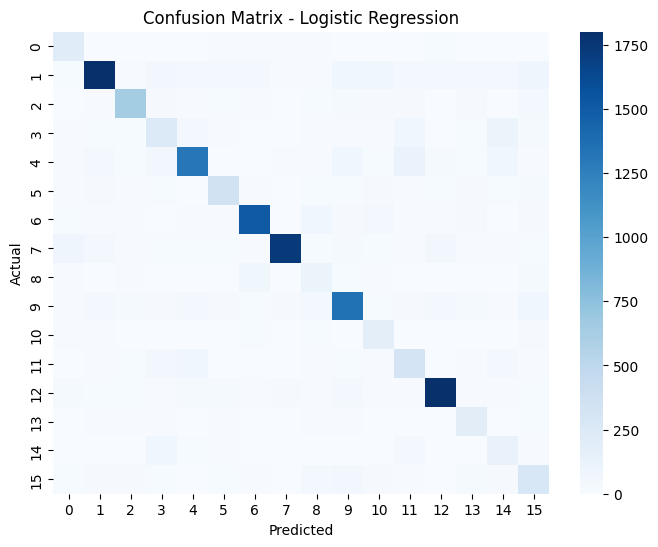

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


# Logistic Regression Model Testing

In [ ]:
samples = [
    "وين اقرب مطعم كشري؟",
    "وش الأخبار عندكم اليوم",
    "شنو أحسن قهوة في الدوحة؟"
]

samples_clean = [clean_text(s) for s in samples]


samples_tfidf = vectorizer.transform(samples_clean)


preds = clf.predict(samples_tfidf)


for s, p in zip(samples, preds):
    print("-" * 50)
    print(f"الجملة : {s}")
    print(f"التوقع  : {p}")

--------------------------------------------------
الجملة : وين اقرب مطعم كشري؟
التوقع  : Qatar
--------------------------------------------------
الجملة : وش الأخبار عندكم اليوم
التوقع  : saudi
--------------------------------------------------
الجملة : شنو أحسن قهوة في الدوحة؟
التوقع  : Qatar


# Dataset Formatting for Transformer Models

**Train–Validation Split Strategy**

In [ ]:
# Train / Validation split

RANDOM_SEED = 42 # Define RANDOM_SEED for reproducibility

train_df, val_df = train_test_split(
    df[[TEXT_COL, 'label_encoded']],
    test_size=0.15,
    stratify=df['label_encoded'],
    random_state=RANDOM_SEED
)

train_df = train_df.reset_index(drop=True);
val_df = val_df.reset_index(drop=True);

print("\nTrain shape:", train_df.shape)
print("Val shape:", val_df.shape)


Train shape: (95200, 2)
Val shape: (16800, 2)


In [ ]:
# Convert to HuggingFace Dataset
train_ds = Dataset.from_pandas(train_df.rename(columns={TEXT_COL: 'text', 'label_encoded': 'label'}))
val_ds = Dataset.from_pandas(val_df.rename(columns={TEXT_COL: 'text', 'label_encoded': 'label'}))
datasets = DatasetDict({"train": train_ds, "validation": val_ds})

# MARBERT Model

In [ ]:
# Tokenizer & Model (MARBERT)

MODEL_NAME = "UBC-NLP/MARBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# Tokenize function
def preprocess(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

tokenized_datasets = datasets.map(preprocess, batched=True)

# Data collator (handles dynamic padding)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/95200 [00:00<?, ? examples/s]

Map:   0%|          | 0/16800 [00:00<?, ? examples/s]

In [ ]:
# Load model for sequence classification
num_labels = len(label2id)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# If GPU available, print info
device = "cuda" if torch.cuda.is_available() else "cpu"
print("\nDevice:", device)
model.to(device)

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Device: cuda


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(100000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

**Training Configuration and Model Setup**

In [ ]:
# TrainingArguments & Trainer

output_dir = "./marbert_dialect_model"

os.environ["WANDB_DISABLED"] = "true"

training_args = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.02,
    num_train_epochs=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    save_total_limit=2,
    fp16=torch.cuda.is_available(),  # use mixed precision if CUDA available
    logging_dir="./logs",
    logging_steps=200,
    optim="adamw_torch" # Explicitly use PyTorch's AdamW implementation to avoid 'fused=True' issue
)

# Early stopping callback
callbacks = [EarlyStoppingCallback(early_stopping_patience=1)]

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=callbacks
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-1998929463.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


**Model Training**

In [ ]:
# Train
train_output = trainer.train()
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.776800,0.709213,0.776310,0.643422


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.776800,0.709213,0.776310,0.643422
2,0.565700,0.667120,0.792500,0.675088


('./marbert_dialect_model/tokenizer_config.json',
 './marbert_dialect_model/special_tokens_map.json',
 './marbert_dialect_model/vocab.txt',
 './marbert_dialect_model/added_tokens.json',
 './marbert_dialect_model/tokenizer.json')

# Analysis

In [ ]:
# Metrics (accuracy + macro F1)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1_macro": f1["f1"]}

In [ ]:
# Evaluation on validation set

eval_results = trainer.evaluate()
print("\nEvaluation results on validation set:")
print(eval_results)


Evaluation results on validation set:
{'eval_loss': 0.6671201586723328, 'eval_accuracy': 0.7925, 'eval_f1_macro': 0.6750877332388107, 'eval_runtime': 32.4519, 'eval_samples_per_second': 517.69, 'eval_steps_per_second': 16.178, 'epoch': 2.0}


# confusion matrix ( MARBERT Model )

<Figure size 1000x800 with 0 Axes>

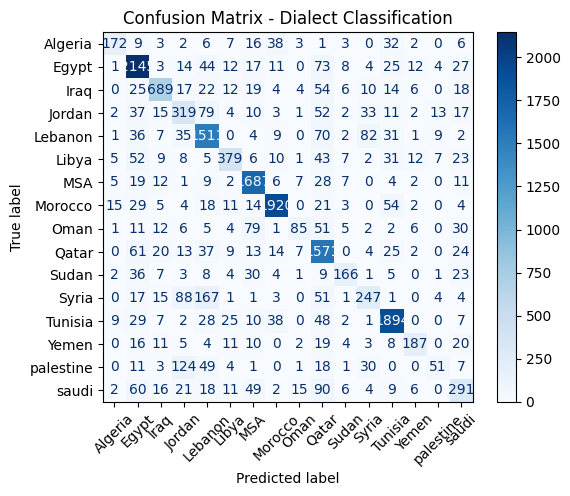

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions from the validation set
preds_output = trainer.predict(tokenized_datasets["validation"])

logits = preds_output.predictions
labels = preds_output.label_ids
preds = np.argmax(logits, axis=-1)

# Build confusion matrix
cm = confusion_matrix(labels, preds)

# Display labels using id2label mapping
disp_labels = [id2label[i] for i in range(len(id2label))]

# Plot
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=disp_labels)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Dialect Classification")
plt.show()

# Training and Validation Loss Visualization

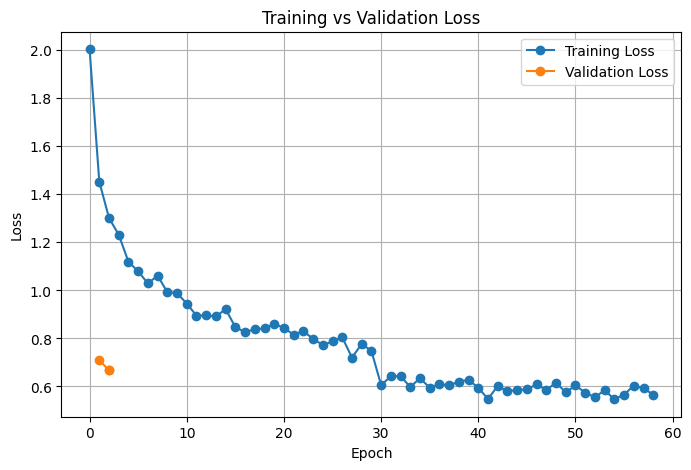

In [ ]:
logs = trainer.state.log_history

train_loss = []
val_loss = []
epochs_val = []

for entry in logs:
    # Training loss
    if "loss" in entry and "eval_loss" not in entry:
        train_loss.append(entry["loss"])

    # Validation loss
    if "eval_loss" in entry:
        val_loss.append(entry["eval_loss"])
        epochs_val.append(entry["epoch"])


# Plot

plt.figure(figsize=(8,5))

plt.plot(range(len(train_loss)), train_loss, label="Training Loss", marker='o')
plt.plot(epochs_val, val_loss, label="Validation Loss", marker='o')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# Inference function (example)

from transformers import pipeline
clf = pipeline("text-classification", model=output_dir, tokenizer=output_dir, device=0 if torch.cuda.is_available() else -1, return_all_scores=False)

def predict(texts):
    preds = clf(texts)
    # pipeline returns label names like "LABEL_0", so map if necessary
    # Here model was saved with id2label so pipeline should return human labels
    return preds

Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [ ]:
# Test texts

texts = [
    "وين بقدر أشتري شرشف طاولة؟",
    "ايه يا عم الكلام ده ",
    "السلام عليكم، كيف حالكم اليوم?", #
    "كيفاش",
    "شنية القيمة اليوم؟", # tunis
    "وين اطيق احول فلوسي؟", # iraq
    "عافاك قول ليه ياماضا عيطات.", # moroco
    "أبشر",
    "هل تعيش بالقرب من اهني؟", # oman
    "في زول بيساعدني. شكرا ليك.", #sudan
    "سولفنا واجد"
]


predictions = predict(texts)


for text, pred in zip(texts, predictions):
    print(f"Text: {text}")
    print(f"Predicted Dialect: {pred['label']}, Score: {pred['score']:.4f}")
    print("-"*40)

Text: وين بقدر أشتري شرشف طاولة؟
Predicted Dialect: Lebanon, Score: 0.6152
----------------------------------------
Text: ايه يا عم الكلام ده 
Predicted Dialect: Egypt, Score: 0.9954
----------------------------------------
Text: السلام عليكم، كيف حالكم اليوم?
Predicted Dialect: MSA, Score: 0.7800
----------------------------------------
Text: كيفاش
Predicted Dialect: Tunisia, Score: 0.4734
----------------------------------------
Text: شنية القيمة اليوم؟
Predicted Dialect: Tunisia, Score: 0.9960
----------------------------------------
Text: وين اطيق احول فلوسي؟
Predicted Dialect: Iraq, Score: 0.9911
----------------------------------------
Text: عافاك قول ليه ياماضا عيطات.
Predicted Dialect: Morocco, Score: 0.9972
----------------------------------------
Text: أبشر
Predicted Dialect: Qatar, Score: 0.3908
----------------------------------------
Text: هل تعيش بالقرب من اهني؟
Predicted Dialect: Oman, Score: 0.8874
----------------------------------------
Text: في زول بيساعدني. شكرا ليك

In [ ]:
# @title Dialect Prediction Interface

text_input = "وش هذا" # @param {type:"string"}

pred = predict([text_input])[0]

print(" النص:", text_input)
print(f" اللهجة المتوقعة: {pred['label']}")
print(f" score: {pred['score']:.4f}")


 النص: وش هذا
 اللهجة المتوقعة: saudi
 score: 0.8354


# Interface for MARBERT

In [ ]:
!pip install -q gradio transformers torch


In [ ]:
import gradio as gr
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "./marbert_dialect_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()


label_map = {
    0: "Algeria",
    1: "Egypt",
    2: "Iraq",
    3: "Jordan",
    4: "Lebanon",
    5: "Libya",
    6: "MSA",
    7: "Morocco",
    8: "Oman",
    9: "Qatar",
    10: "Sudan",
    11: "Syria",
    12: "Tunisia",
    13: "Yemen",
    14: "palestine",
    15: "saudi"
}



def clean_text(text):
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    return text.strip()


def predict_dialect(text):
    if text.strip() == "":
        return "Please enter an Arabic sentence."

    text = clean_text(text)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_id = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_id].item()

    dialect = label_map.get(pred_id, "Unknown")

    return f"Predicted Dialect: {dialect}\nConfidence: {confidence:.2%}"


interface = gr.Interface(
    fn=predict_dialect,
    inputs=gr.Textbox(lines=2, placeholder="اكتب الجملة باللهجة هنا"),
    outputs=gr.Textbox(),
    title="Arabic Dialect Detection Chatbot (MARBERT)",
    description="Enter an Arabic sentence and the system will detect the dialect."
)

interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ca13b81b9f7c3ec49f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Comparison between MARBERT and Logistic Regression

In [ ]:
# comparison table
comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression (TF-IDF)",
        "MARBERT"
    ],
    "Accuracy": [
        0.7243,
        0.7925
    ],
    "F1 Macro": [
        0.6091,
        0.6751
    ],
    "Training Type": [
        "Traditional Machine Learning",
        "Deep Learning (Transformer)"
    ]
})


comparison_table


,Model,Accuracy,F1 Macro,Training Type
0,Logistic Regression (TF-IDF),0.7243,0.6091,Traditional Machine Learning
1,MARBERT,0.7925,0.6751,Deep Learning (Transformer)


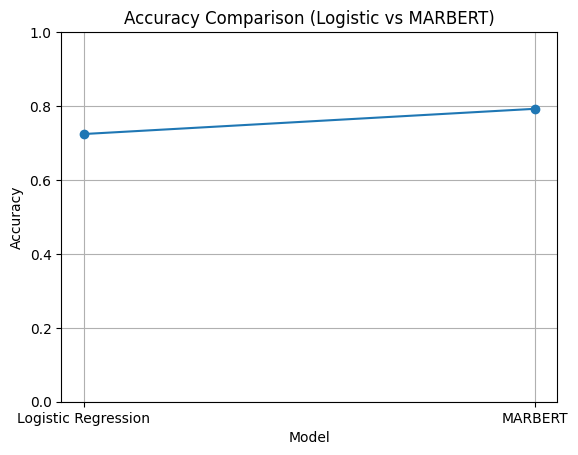

In [ ]:
models = ["Logistic Regression", "MARBERT"]
accuracies = [acc, 0.7925]

plt.figure()
plt.plot(models, accuracies, marker='o')
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison (Logistic vs MARBERT)")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


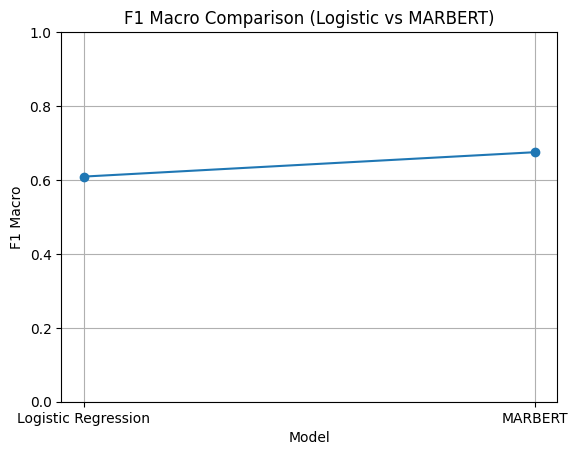

In [ ]:
f1_scores = [f1, 0.675088]

plt.figure()
plt.plot(models, f1_scores, marker='o')
plt.xlabel("Model")
plt.ylabel("F1 Macro")
plt.title("F1 Macro Comparison (Logistic vs MARBERT)")
plt.ylim(0, 1)
plt.grid(True)
plt.show()
